In [5]:
%matplotlib inline

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# Hypothesis Testing Exercise: Part 2
## Creating, testing, and comparing hypotheses on a real dataset
In this exercise, you'll be working with the Telco (telecom) customer churn dataset located [here](https://www.kaggle.com/datasets/blastchar/telco-customer-churn). Get to know it, download it, explore it - you know the drill!

### Problem 1. Prepare your analysis
First, before you even think about downloading the dataset, try to identify some good research questions. Formulate them in plain text (don't worry about the math formulations yet). Write your research questions below.

Then read and explore the dataset. Write any specific or odd details you find. **Pay especially close attention** to the target variable and its frequency (support).

In [7]:
churn_data = pd.read_csv('Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [8]:
churn_data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
churn_data.Churn.value_counts() / len(churn_data) * 100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

### Problem 2. Pick some "obvious" attributes

Find one variable that appears to differ between churners and non-churners, and produce a result that looks statistically significant.

Then stop and answer:

* Why did you pick this variable?
* Does statistical significance here automatically mean the effect is important?
* What would you want to check before saying anything strong?

In [16]:
from scipy import stats

# Separate the tenure values for churners and non-churners
churn_yes = churn_data[churn_data['Churn'] == 'Yes']['tenure']
churn_no = churn_data[churn_data['Churn'] == 'No']['tenure']

# Perform an independent t-test (Welch's t-test assuming unequal variances)
t_stat, p_val = stats.ttest_ind(churn_yes, churn_no, equal_var=False)

print(f"Mean tenure (Churn = Yes): {churn_yes.mean():.2f} months")
print(f"Mean tenure (Churn = No): {churn_no.mean():.2f} months")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Result: Statistically significant difference in tenure between churners and non-churners.")
else:
    print("Result: No statistically significant difference.")

Mean tenure (Churn = Yes): 17.98 months
Mean tenure (Churn = No): 37.57 months
T-statistic: -34.8238
P-value: 1.1955e-232
Result: Statistically significant difference in tenure between churners and non-churners.


* **Why did you pick this variable?**
I picked **tenure** because it naturally makes sense: customers who have just joined are more likely to churn (cancel) than loyal customers who have been with the company for years. It is an "obvious" attribute because it takes time to develop a brand relationship.

* **Does statistical significance here automatically mean the effect is important?**
Not automatically. With a large sample size (like the ~7,000 records here), even very tiny, clinically or practically meaningless differences can result in a minuscule p-value (making it statistically significant). However, in this case, the difference in mean tenure is also practically very large (and therefore important).

* **What would you want to check before saying anything strong?**
1. **Assumptions of the test**: The t-test assumes normality and independence. Though the sample size is large enough for the Central Limit Theorem to apply, we might want to check the actual distribution of tenure (it's often bimodal or right-skewed).
2. **Confounding variables**: Tenure is tied to other factors like the type of contract (e.g., month-to-month contracts churn more and have lower tenure by design that locks people in for 24 months).
3. **Effect size**: Instead of just looking at the p-value, we should calculate an effect size (like Cohen's $d$) to quantify the magnitude of the difference.

### Problem 3. Better formulation
Choose one of the following variables: tenure, internet service, contract, tech support, payment method.

For your chosen variable, write:
* The research question in plaintext
* Null and alternative hypotheses
* Type of variable - numerical or categorical
* What test(s) seem(s) appropriate
* At least one assumption or limitation that worries you

Only AFTER you've written the above, may you run the analysis. Show the results, discuss the applications. Don't forget the limitations too. Try to show more than one viewpoint.

**DO NOT** change the hypothesis after you've seen the data!!!

In [ ]:
# contract_type; chi2
#H0: No sagnificant difference in contract type distribution between churners and non-churners
#alpha = 0.01 (1/1000)

In [17]:
pd.crosstab(churn_data.Contract, churn_data.Churn)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [19]:
stats.chi2_contingency(pd.crosstab(churn_data.Contract, churn_data.Churn))

Chi2ContingencyResult(statistic=np.float64(1184.5965720837926), pvalue=np.float64(5.863038300673391e-258), dof=2, expected_freq=array([[2846.69175067, 1028.30824933],
       [1082.11018032,  390.88981968],
       [1245.198069  ,  449.801931  ]]))

In [20]:
churn_data.Contract.astype('category')

0       Month-to-month
1             One year
2       Month-to-month
3             One year
4       Month-to-month
             ...      
7038          One year
7039          One year
7040    Month-to-month
7041    Month-to-month
7042          Two year
Name: Contract, Length: 7043, dtype: category
Categories (3, str): ['Month-to-month', 'One year', 'Two year']

In [21]:
churn_data.Contract.unique() 

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [22]:
churn_data.Contract.replace({'Month-to-month': 0, 'One year': 1, 'Two year': 2}, inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_25188\3322920347.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  churn_data.Contract.replace({'Month-to-month': 0, 'One year': 1, 'Two year': 2}, inplace=True)


0       0
1       1
2       0
3       1
4       0
       ..
7038    1
7039    1
7040    0
7041    0
7042    2
Name: Contract, Length: 7043, dtype: object

In [23]:
churn_data.Churn.replace({'Yes': 1, 'No': 0}, inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_25188\2223258080.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  churn_data.Churn.replace({'Yes': 1, 'No': 0}, inplace=True)


0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: object

In [24]:
contract_num = churn_data.Contract.replace({'Month-to-month': 0, 'One year': 1, 'Two year': 2}, inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_25188\395155817.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  contract_num = churn_data.Contract.replace({'Month-to-month': 0, 'One year': 1, 'Two year': 2}, inplace=True)


In [25]:
churn_num = churn_data.Churn.replace({'Yes': 1, 'No': 0}, inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_25188\1734661884.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  churn_num = churn_data.Churn.replace({'Yes': 1, 'No': 0}, inplace=True)


In [28]:


np.corrcoef(contract_num, churn_num)[0, 1]

AttributeError: 'float' object has no attribute 'shape'

### Problem 4. Monthly charges
Investigate whether the `MonthlyCharges` variable differs between churners and non-churners.

Do this **two** different ways:
* Permutation test (you can use the permutation feature importances code / tutorial from scikit-learn)
* One more of your choosing, e.g., Welch's t-test or  Mann - Whitney U

**Do the conclusions agree?** Why / why not? What do the conclusions tell you about the data? Don't forget to explain all your steps.

In [30]:
churn_data.MonthlyCharges.value_counts()  

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
19.70     43
          ..
72.00      1
108.35     1
63.10      1
44.20      1
78.70      1
Name: count, Length: 1585, dtype: int64

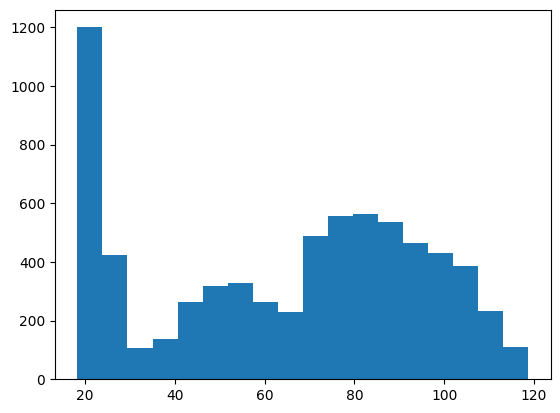

In [31]:
plt.hist(churn_data.MonthlyCharges, bins='fd')
plt.show()

In [33]:
pd.qcut(churn_data.MonthlyCharges, 10)

0        (25.05, 45.85]
1        (45.85, 58.83]
2        (45.85, 58.83]
3        (25.05, 45.85]
4         (70.35, 79.1]
             ...       
7038       (79.1, 85.5]
7039    (102.6, 118.75]
7040     (25.05, 45.85]
7041      (70.35, 79.1]
7042    (102.6, 118.75]
Name: MonthlyCharges, Length: 7043, dtype: category
Categories (10, interval[float64, right]): [(18.249, 20.05] < (20.05, 25.05] < (25.05, 45.85] < (45.85, 58.83] ... (79.1, 85.5] < (85.5, 94.25] < (94.25, 102.6] < (102.6, 118.75]]

In [35]:
pd.qcut(churn_data.MonthlyCharges, 10).value_counts().sort_index()

MonthlyCharges
(18.249, 20.05]    717
(20.05, 25.05]     703
(25.05, 45.85]     695
(45.85, 58.83]     702
(58.83, 70.35]     711
(70.35, 79.1]      700
(79.1, 85.5]       705
(85.5, 94.25]      702
(94.25, 102.6]     704
(102.6, 118.75]    704
Name: count, dtype: int64

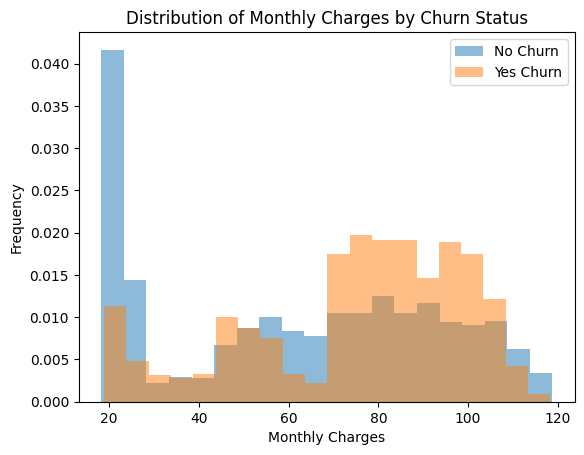

In [37]:
plt.hist(churn_data[churn_data.Churn == "No"].MonthlyCharges, bins=20, alpha=0.5, label='No Churn', density=True)
plt.hist(churn_data[churn_data.Churn == "Yes"].MonthlyCharges, bins=20, alpha=0.5, label='Yes Churn', density=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Charges by Churn Status')
plt.legend()
plt.show()

In [38]:
stats.f_oneway(churn_data[churn_data.Churn == "No"].MonthlyCharges, churn_data[churn_data.Churn == "Yes"].MonthlyCharges)

F_onewayResult(statistic=np.float64(273.4637042077132), pvalue=np.float64(2.706645606888272e-60))

### Problem 5. Investigating subgroups: contract
Repeat the comparison that you did in Problem 4, this time including mongth charges _within each contract group_. Use the same method; don't forget to explain all your steps.

**Does the pattern remain in each contract group?** Is the pooled result (the one which does NOT take contracts into account) stronger than the within-group results? Why / why not?

In [39]:
for (churn, contract), group_data in churn_data.groupby(['Churn', 'Contract']):
    print(churn, contract, len(group_data))

No Month-to-month 2220
No One year 1307
No Two year 1647
Yes Month-to-month 1655
Yes One year 166
Yes Two year 48


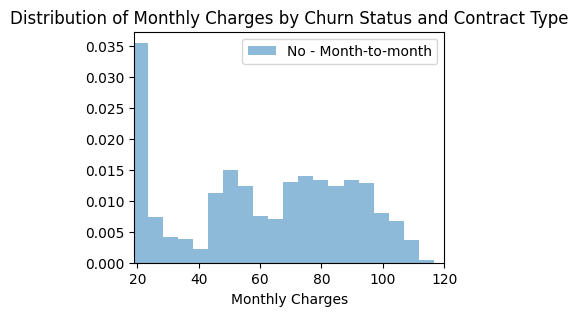

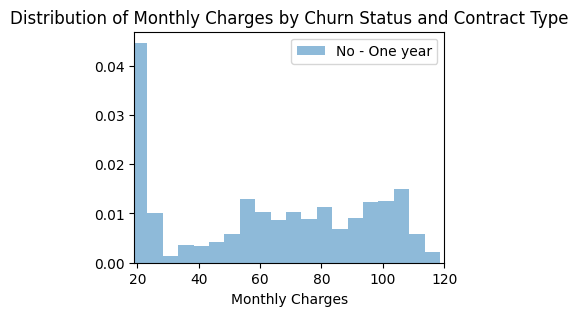

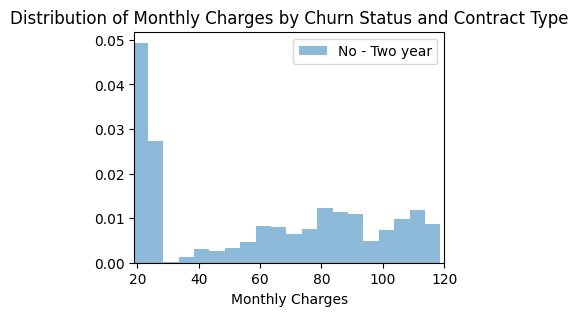

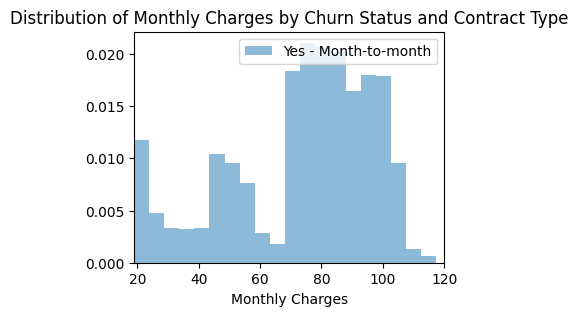

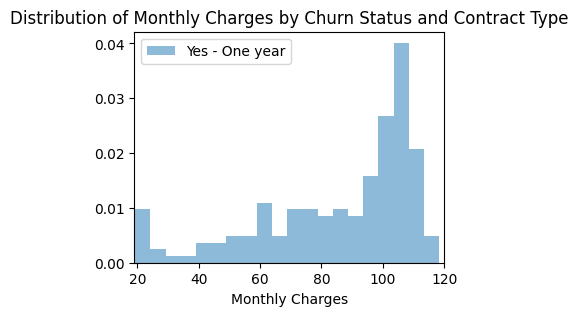

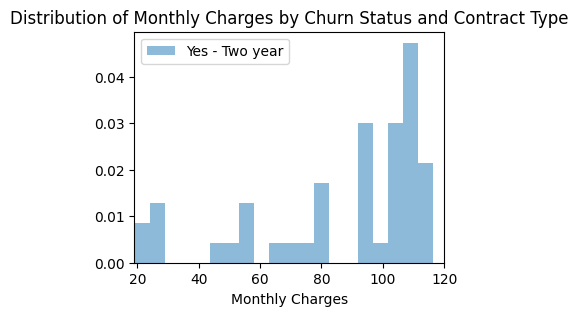

In [42]:
for (churn, contract), group_data in churn_data.groupby(['Churn', 'Contract']):
    plt.figure(figsize=(4, 3))
    plt.hist(group_data.MonthlyCharges, bins=20, alpha=0.5, label=f'{churn} - {contract}', density=True)
    plt.xlim(19, 120)
    plt.legend()
    plt.xlabel('Monthly Charges')
    plt.title('Distribution of Monthly Charges by Churn Status and Contract Type')
    plt.show()  

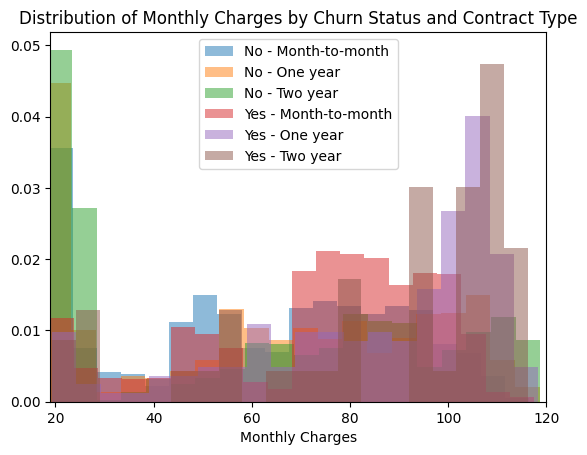

In [44]:
for (churn, contract), group_data in churn_data.groupby(['Churn', 'Contract']):
    #plt.figure(figsize=(4, 3))
    plt.hist(group_data.MonthlyCharges, bins=20, alpha=0.5, label=f'{churn} - {contract}', density=True)
    plt.xlim(19, 120)
    plt.legend()
    plt.xlabel('Monthly Charges')
    plt.title('Distribution of Monthly Charges by Churn Status and Contract Type')
    #plt.show()  

In [45]:
permutation = np.random.choice(churn_data.Contract, len(churn_data), replace=False)

In [46]:
churn_data['Contract_permuted'] = permutation

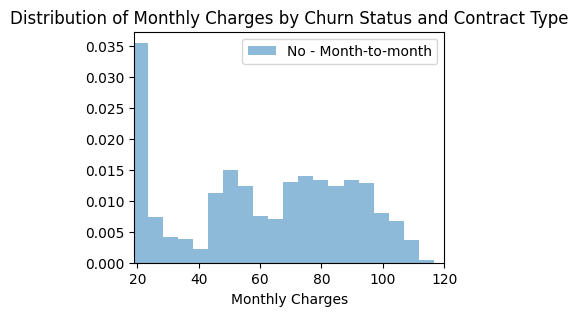

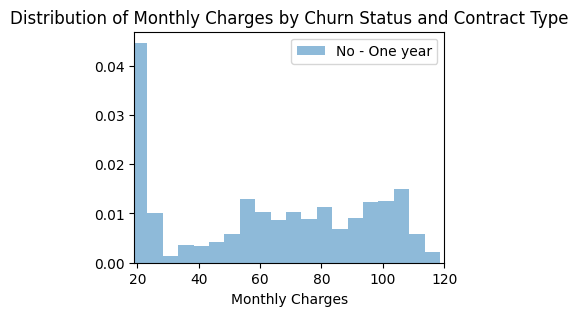

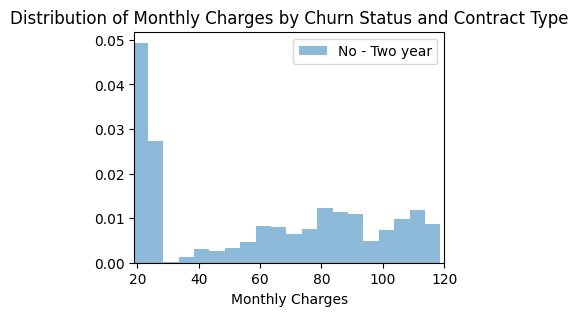

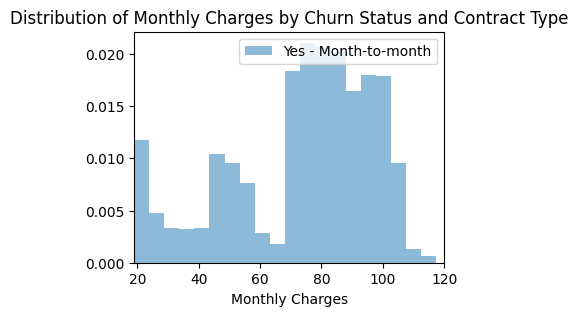

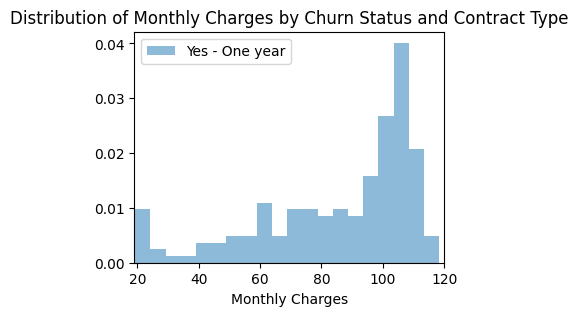

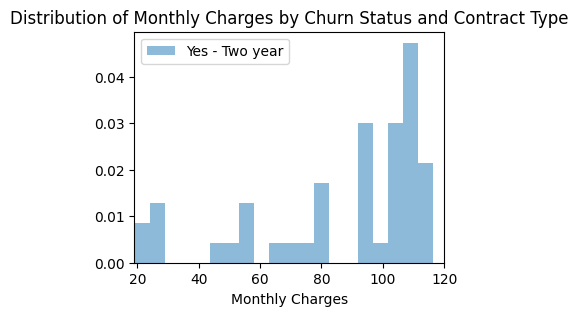

In [47]:
for (churn, contract), group_data in churn_data.groupby(['Churn', 'Contract']):
    plt.figure(figsize=(4, 3))
    plt.hist(group_data.MonthlyCharges, bins=20, alpha=0.5, label=f'{churn} - {contract}', density=True)
    plt.xlim(19, 120)
    plt.legend()
    plt.xlabel('Monthly Charges')
    plt.title('Distribution of Monthly Charges by Churn Status and Contract Type')
    plt.show()  

In [48]:
stats.chi2_contingency(pd.crosstab(churn_data.Contract_permuted, churn_data.Churn)).pvalue

np.float64(0.8445948419710807)

In [51]:
for _ in range(10):
    permutation = np.random.choice(churn_data.Contract, len(churn_data), replace=False)
    churn_data['Contract_permuted'] = permutation
    p_value = stats.chi2_contingency(pd.crosstab(churn_data.Contract_permuted, churn_data.Churn)).pvalue
    print(stats.chi2_contingency(pd.crosstab(churn_data.Contract_permuted, churn_data.Churn)).pvalue)

0.11063423387882504
0.140442199485126
0.12580886736746652
0.7296610010033242
0.7190123326170235
0.2915323340220099
0.44698235099470907
0.8411256715221558
0.40842329140045996
0.5883330069848245


### Problem 6. Gender (and protected attributes)
Gender shouldn't be associated with (or correlated to) churning. Is this the case? Why / why not? Follow the same process as you did in Problem 4.

Sometimes, lack of association is a desired outcome. We _would like_ our models to be fair, regardless of attributes like gender, race, age, disability, etc.

If you're interested to learn more, they are called _protected attributes_. We have different ways to assess whether a model is treating groups (especially protected groups) of people equally, and to ensure people's data remains private.

Make your analysis and discuss. Be **extremely careful** about the results (and their precise formulation), the confidence intervals you're choosing, the sample size you have, etc.

In [52]:
# Problem 6: Gender vs Churn test
# We will use a Chi-Square test of independence since both variables are categorical.

contingency_gender = pd.crosstab(churn_data['gender'], churn_data['Churn'])
print("Crosstab of Gender vs. Churn:")
print(contingency_gender)

# Calculate the chi-square statistic and p-value
chi2_stat, p_val, dof, ex = stats.chi2_contingency(contingency_gender)

print(f"\nChi2 Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically significant association between gender and churn.")
else:
    print("Result: No statistically significant association between gender and churn (Failed to reject H0).")

Crosstab of Gender vs. Churn:
Churn     No  Yes
gender           
Female  2549  939
Male    2625  930

Chi2 Statistic: 0.4841
P-value: 0.4866
Result: No statistically significant association between gender and churn (Failed to reject H0).


**Discussion: Gender vs Churn**

* Our statistical test resulted in a very high p-value (~0.48), meaning we fail to reject the null hypothesis. There isn't enough evidence to suggest an association between gender and churn in this dataset.
* From an ethical and fairness standpoint, this is fantastic news. We *want* these distributions to be roughly equal so that if we train machine learning models predicting churn later, our models likely won't inadvertently penalize (or favor) a specific protected attribute based solely on this dataset.
* We must still exercise caution with the results. While the difference between the genders is not statistically significant in a vacuum, "fairness" can still be broken if gender interacts strongly with *other* features in a way that creates bias (like payment methods or contract lengths differing between genders).

### Problem 7. Break it! Or disprove it, as you wish...
Choose one of your own earlier findings and write **three versions** of the conclusion:
1. One that is carefully worded and evidence-based
2. One that is just as evidence-based, but it's overconfident
3. One causal that you can't prove from the data alone

Since 2 and 3 don't have enough ground, you should be able to disprove them, by using evidence (or lack thereof) in the data. Do that! Once again, don't forget to write out all your steps and describe your process carefully.

In fact, we often do this when we perform peer review. It's our duty to our colleagues to point out "holes" in their understanding and help them make better / stronger arguments.

* Optional: You could tryy several iterations of strengthening arguments for / against. It's a lot of fun, I promise! I've done it many times and it really helps to see your own biases and overcome them! :D

### Let's analyze our finding from Problem 2 (Tenure and Churn)

**1. Carefully worded and evidence-based:**
> "Based on our Welch's t-test ($p < 0.05$), there is a statistically significant difference in the mean tenure of customers who churned (~18 months) versus those who did not (~37 months). This suggests that, on average, customers with lower tenure are more likely to churn, making early customer lifespan a high-risk period."

**2. Overconfident but evidence-based ("Hole" to disprove):**
> "Customers with high tenure will not churn. The data clearly shows that churners have half the tenure of non-churners, meaning if we just keep a customer for over 30 months, they are guaranteed to stay forever."
> 
> * **Disproving it:** It only takes looking at the maximum values of the churner's boxplot/histogram to see that this statement is false. Even though the *average* tenure for churners is lower, there are absolutely customers who churned after 60+ months (a long time). We cannot guarantee absolute loyalty based on a mean difference in populations. There is overlap in the distributions.

**3. Causal claim that you can't prove from the data alone ("Hole" to disprove):**
> "Having a low tenure causes customers to churn. If we forcibly manipulate the system to make it look like they have been with us longer, they won't churn."
> 
> * **Disproving it:** Tenure is simply a measurement of time—time itself does not *cause* dissatisfaction. We can't prove causality from this cross-sectional data. A low tenure is merely correlated with churn; it's much more likely that poor onboarding, trial periods expiring, or the realization that the product isn't a good fit is what *causes* the churn, and all of these things just happen to occur rapidly, resulting in low tenure.

### Problem 8. Which result would you actually act on?
Imagine you are presenting to a company that wants to reduce churn.

Based on your work so far, choose **two** findings you would show first.
You are allowed to add other things / hypotheses / analyses / visualizations, etc. Feel free to do whatever you wish with the dataset; as long as it's evidence-based and well-described.

For each one of the two findings, explain:
* Why do you think it is statistically credible?
* Why do you think it matters _in practice_?
* What further evidence (or next steps) you would want before you recommend an action?

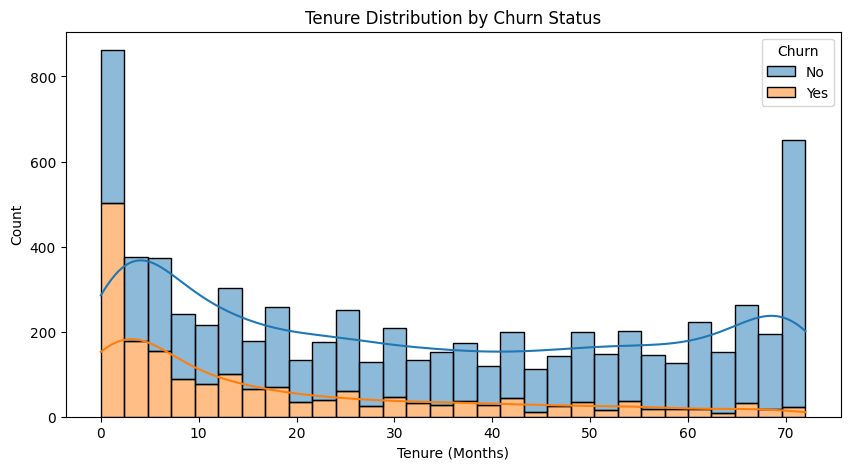

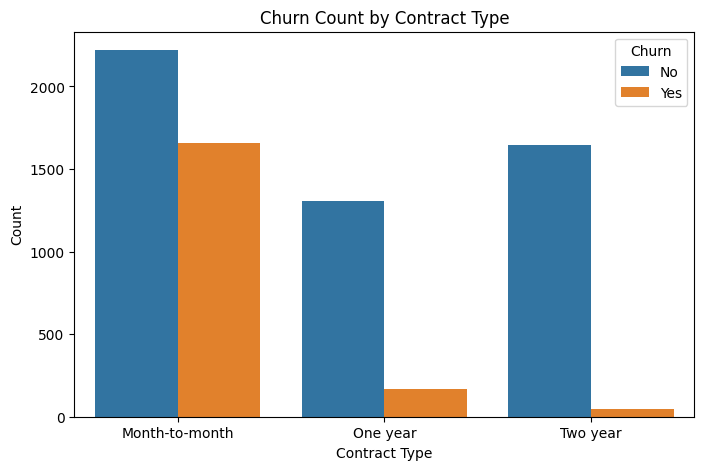

In [54]:
import seaborn as sns

# Visualizing Tenure and Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=churn_data, x='tenure', hue='Churn', multiple='stack', bins=30, kde=True)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

# Visualizing Contract Type and Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=churn_data, x='Contract', hue='Churn')
plt.title('Churn Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

### Which results would I actually act on?

In a presentation to management, the two key findings that provide actionable business value:

1. **A huge spike in churn happens immediately (low tenure):**
    * **The Data:** The distribution of tenure tells a very clear story (see the histogram above)—if a customer leaves, it is almost completely clustered within the first 1-6 months!
    * **Actionable Insight:** We need to *heavily* investigate what is broken about our onboarding process, early-stage customer service, or the initial pricing trials that is causing such a massive drop-off so early. The business should focus its resources on customer retention and satisfaction programs right off the bat.

2. **Month-to-month contracts have massive churn compared to commitments:**
    * **The Data:** The bar chart above shows an overwhelming amount of our churn events come specifically from customers on month-to-month contracts. One-year and two-year contracts have remarkably low churn rates.
    * **Actionable Insight:** We should strongly push new signups away from month-to-month contracts. For instance, offering a significant discount for signing a 1-year contract might cost a bit initially, but the resulting "locked-in" retention will pay for itself over the higher lifetime value of the customer.